###CHANNEL GAIN CODE - OUTDOOR

In [1]:
import numpy as np
import math
import numpy.typing as npt
import pandas as pd
import time
import matplotlib.pyplot as plt

c_free = 3 * 10**8                                    # propagation velocity in the free space [m/s]
h_BS = 3.5                                       # antenna height of the base station [m]
h_UT = 3.5                                       # antenna height of the user terminal [m]
h_E = 1                                          # effective environment height [m]
h_prime_BS = h_BS - h_E                          # effective antenna height of the base station [m]
h_prime_UT = h_UT - h_E                          # effective antenna height of the user terminal [m]

def get_distance2D(p1, p2):
    d = np.sqrt((p1[0] - p2[0]) ** 2 + (p1[1] - p2[1]) ** 2)
    return d

def get_distance3D(p1, p2):
    d = np.sqrt((p1[0] - p2[0]) ** 2 + (p1[1] - p2[1]) ** 2 + (p1[2] - p2[2]) ** 2)
    return d

def get_PL_LOS(p1, p2, f_c):
    d_2D = get_distance2D(p1, p2)
    d_3D = get_distance3D(p1, p2)
    d_BP = (4 * h_prime_BS * h_prime_UT * f_c) / c_free
    if (d_2D < 10):
        if (d_3D >= 1) and (d_3D <= 150):
            PL_LOS = 32.4 + 17.3*math.log10(d_3D) + 20*math.log10(f_c * 10**(-9))
    else:
        if (d_2D >= 10) and (d_2D <= d_BP):
            PL_LOS = 32.4 + 21*math.log10(d_3D) + 20*math.log10(f_c * 10**(-9))
        elif (d_2D >= d_BP) and (d_2D <= 5 * 10**3):
            PL_LOS = 32.4 + 40*math.log10(d_3D) + 20*math.log10(f_c * 10**(-9)) - 9.5*math.log10((d_BP)**2 + (p1[2] - p2[2])**2)
    return PL_LOS

def get_PL_NLOS(p1, p2, f_c):
    d_2D = get_distance2D(p1, p2)
    d_3D = get_distance3D(p1, p2)
    if (d_2D < 10):
        if (d_3D >= 1) and (d_3D <= 150):
            PL_prime_NLOS = 17.3 + 38.3*math.log10(d_3D) + 24.9*math.log10(f_c * 10**(-9))
    else:
        if (d_2D >= 10) and (d_2D <= 5 * 10**3):
            PL_prime_NLOS = 22.4 + 35.3*math.log10(d_3D) + 21.3*math.log10(f_c * 10**(-9)) - 0.3*(p2[2] - 1.5)
    PL_NLOS = max(get_PL_LOS(p1, p2, f_c), PL_prime_NLOS)
    return PL_NLOS

#this function gives the probability that how much of the transmission is in Line of Sight
def get_Pr(p1, p2):
    d_2D = get_distance2D(p1, p2)
    if (d_2D < 10):
        if (d_2D <= 1.2):
            pr_LOS = 1
        elif (d_2D > 1.2) and (d_2D < 6.5):
            pr_LOS = math.exp(-(d_2D - 1.2)/4.7)
        elif (d_2D >= 6.5):
            pr_LOS = math.exp(-(d_2D - 6.5)/32.6) * 0.32
    else:
        if d_2D <= 18:
            pr_LOS = 1
        elif d_2D > 18:
            pr_LOS = (18/d_2D) + (math.exp(-d_2D/36) * (1 - (18/d_2D)))
    return pr_LOS

def get_PL(p1, p2, f_c):
    PL = get_Pr(p1, p2) * get_PL_LOS(p1, p2, f_c) + (1 - get_Pr(p1, p2)) * get_PL_NLOS(p1, p2, f_c)
    return PL

def get_channel_gain(p1, p2, f_c):
    g = 1 / 10**(get_PL(p1, p2, f_c) / 10)
    return np.float64(g)


###CHANNEL GAIN CODE - INDOOR

In [2]:
def get_distance2D(p1, p2):
    return np.hypot(p1[0]-p2[0], p1[1]-p2[1])

def get_distance3D(p1, p2):
    return np.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2 + (p1[2]-p2[2])**2)

# -------- 38.901 InH (Indoor-Office) PATH LOSS --------
def get_PL_LOS_InH(p1, p2, f_c):
    """
    3GPP TR 38.901 InH Office LOS:
      PL_LOS = 32.4 + 17.3*log10(d_3D) + 20*log10(fc_GHz), for 1 m <= d_3D <= 150 m
    """
    d_3D = get_distance3D(p1, p2)
    if d_3D < 1:  # spec validity starts at 1 m
        d_3D = 1.0
    if d_3D > 150:
        d_3D = 150.0
    fc_GHz = f_c * 1e-9
    PL_LOS = 32.4 + 17.3*math.log10(d_3D) + 20.0*math.log10(fc_GHz)
    return PL_LOS

def get_PL_NLOS_InH(p1, p2, f_c):
    """
    3GPP TR 38.901 InH Office NLOS (use max with LOS):
      PL'_NLOS = 38.3*log10(d_3D) + 17.30*log10(fc_GHz) + 24.9, for 1 m <= d_3D <= 150 m
      PL_NLOS = max(PL_LOS, PL'_NLOS)
    """
    d_3D = get_distance3D(p1, p2)
    if d_3D < 1:
        d_3D = 1.0
    if d_3D > 150:
        d_3D = 150.0
    fc_GHz = f_c * 1e-9
    PL_LOS = get_PL_LOS_InH(p1, p2, f_c)
    PLp_NLOS = 38.3*math.log10(d_3D) + 17.30*math.log10(fc_GHz) + 24.9
    return max(PL_LOS, PLp_NLOS)

# -------- LOS PROBABILITY (choose 'open' or 'mixed') --------
def get_Pr_InH(p1, p2, office_type='open'):
    """
    InH LOS probability from TR 38.901 Table 7.4.2-1.
    office_type: 'open' (default) or 'mixed'
    Uses d_in-2D (horizontal) in meters.
    """
    d = get_distance2D(p1, p2)
    if office_type == 'mixed':
        if d <= 1.2:
            return 1.0
        elif d < 6.5:
            return math.exp(-(d - 1.2)/4.7)
        else:
            return 0.32 * math.exp(-(d - 6.5)/32.6)
    else:  # 'open' office
        if d <= 5.0:
            return 1.0
        elif d < 49.0:
            return math.exp(-(d - 5.0)/70.0)
        else:
            return 0.54 * math.exp(-(d - 49.0)/211.7)

def get_PL_InH(p1, p2, f_c, office_type='open'):
    pr = get_Pr_InH(p1, p2, office_type)
    PL_los = get_PL_LOS_InH(p1, p2, f_c)
    PL_nlos = get_PL_NLOS_InH(p1, p2, f_c)
    return pr*PL_los + (1.0 - pr)*PL_nlos

def get_channel_gain_InH(p1, p2, f_c, office_type='open'):
    """
    Returns linear power gain g = 10^(-PL/10)
    """
    PL = get_PL_InH(p1, p2, f_c, office_type)
    return 10.0**(-PL/10.0)


###COMPUTE C BOUNDS

In [3]:
def compute_c_bounds(h, P_max, eta):
    N = len(h)
    sum1 = np.sum(h * np.sqrt(P_max) / np.sqrt(eta))

    print("For number of transmitters: ",N)
    c_lower = 0
    for i in range(N):
        me = h[i] * np.sqrt(P_max[i]) / np.sqrt(eta)
        other = sum1 - me
        c_low = (np.sqrt(eta) / (2 * np.sqrt(P_max[i]) * np.abs(h[i]))) * np.exp(EXP_POWER_UTILITY * other)

        c_lower = max(c_lower, c_low)

    return c_lower


###UTILITY FUNCTION AND CLOSED FORM POWER FUNCTION

In [4]:

def utility_vector(
    P: npt.NDArray[np.float64],
    h: npt.NDArray[np.float64],
    c: np.float64,
    eta: np.float64
):
    utilities = np.zeros(len(P))
    sum1 = np.float64(0.0)
    for i in range(len(P)):
        sum1 += h[i] * np.sqrt(P[i]) / np.sqrt(eta)

    for i in range(len(P)):
        me = h[i] * np.sqrt(P[i]) / np.sqrt(eta)
        other = sum1 - me
        utilities[i] = me * np.exp(EXP_POWER_UTILITY *other) - c * np.power(me, 2)
    return utilities

def closed_form_p_star(
    h: npt.NDArray[np.float64],
    c: np.float64,
    eta: np.float64,
    P_max: npt.NDArray[np.float64],
    P: npt.NDArray[np.float64]
):
    sum1 = np.float64(0.0)
    for i in range(len(P)):
        sum1 += h[i] * np.sqrt(P[i]) / np.sqrt(eta)

    P_star = np.zeros(len(P))
    for i in range(len(P)):
        me = h[i] * np.sqrt(P[i]) / np.sqrt(eta)
        other = sum1 - me
        P_star[i] = eta * np.exp(2* EXP_POWER_UTILITY *other)/ (4 * np.power(c, 2) * np.power(h[i], 2))

    P_star = np.clip(P_star, 0, P_max)
    return P_star


###OPTIMAL ETA FUNCTION

In [5]:
def optimal_eta(h: npt.NDArray[np.float64], P: npt.NDArray[np.float64], sigma2: np.float64):
    num = np.float64(0.0)
    for i in range(len(h)):
        num += np.power(h[i], 2) * P[i]
    num += sigma2
    den = np.float64(0.0)
    for i in range(len(h)):
        den += h[i] * np.sqrt(P[i])

    eta_star = (num / den)**2
    return eta_star


###MSE FUNCTION

In [6]:
def mse(P: npt.NDArray[np.float64], h: npt.NDArray[np.float64], eta: np.float64, sigma2: np.float64):
    mse = np.float64(0.0)
    for i in range(len(h)):
        mse += np.power(h[i] * np.sqrt(P[i]) / np.sqrt(eta) - np.float64(1.0), 2)
    mse += sigma2 / eta
    mse /= np.power(len(h), 2)
    return mse

###ADAPTIVE ETA BEST RESPONSE

In [7]:
def adaptive_eta_best_response(
    h: npt.NDArray[np.float64],
    eta_init: np.float64,
    epsilon_p: np.float64,
    epsilon_mse: np.float64,
    P_max: npt.NDArray[np.float64],
    sigma2: np.float64,
    c: np.float64,
    max_iter: int = 1000
):

    iteration_eta = 0
    convergence_eta = 0

    P_current = np.random.uniform(0, P_max, len(h))
    #print(P_current)
    eta_current = eta_init

    eta_history: list[np.float64] = [eta_current]
    mse_history: list[np.float64] = [mse(P_current, h, eta_current, 0)]
    power_outer_history: list[list[npt.NDArray[np.float64]]] = []
    utility_outer_history: list[list[npt.NDArray[np.float64]]] = []

    while (convergence_eta == 0) and (iteration_eta < max_iter):
        iteration_eta += 1
        # print(f"\n=== η Iteration {iteration_eta} | Current η = {eta_current:.4e} ===")

        # ----- Inner loop: Best Response on Power -----
        convergence_p = 0
        iteration_p = 0

        power_history = []
        utility_history = []
        if iteration_eta == 0:
            utility_history.append(utility_vector(P_current, h, c, eta_current))
            power_history.append(P_current.copy())


        while (convergence_p == 0)and (iteration_p < max_iter) :
            iteration_p += 1

            P_new = closed_form_p_star(h, c, eta_current, P_max, P_current)
            utility_new = utility_vector(P_new, h, c, eta_current)

            power_history.append(P_new.copy())
            utility_history.append(utility_new.copy())

            # Check convergence in Power
            all_satisfy_epsilon_p = 1
            for i in range(len(P_current)):
                if np.abs(P_new[i] - P_current[i]) >= epsilon_p:
                    all_satisfy_epsilon_p = 0

            if all_satisfy_epsilon_p:
                convergence_p = 1

            P_current = P_new

        # ----- After Power Convergence -----
        P_star = P_current.copy()
        power_outer_history.append(power_history)
        utility_outer_history.append(utility_history)

        # Compute η
        eta_new = optimal_eta(h, P_star, sigma2)
        eta_history.append(eta_new)
        eta_current = eta_new

        # COMPUTE MSE
        mse_eta = mse(P_star, h, eta_current, sigma2)
        mse_history.append(mse_eta)


        # Print statements for debugging and tracking convergence
        # print(f"  → Inner loop converged in {iteration_p} iterations (ε_p={epsilon_p:.1e})")
        # if len(mse_history) > 1:
            # print(f"  → MSE difference from previous iteration: {np.abs(mse_history[-1] - mse_history[-2]):.4e}")

        if len(mse_history) > 1 and np.abs(mse_history[-1] - mse_history[-2]) < epsilon_mse:
            convergence_eta = 1
            # print("  ✓ Converged in η based on MSE threshold.")


    # print("\n=== Summary ===")
    # print(f"Total Outer Iterations: {iteration_eta}")
    # print(f"Average Inner Iterations per Outer: {np.mean([len(ph) for ph in power_outer_history]):.2f}")


    df = pd.DataFrame({
        "Node": np.arange(1, len(h) + 1),
        "Final Power P*": power_outer_history[-1][-1],
        "Final Utility": utility_outer_history[-1][-1],
        "Channel Gain h": h
    })

    return df, power_outer_history, utility_outer_history, mse_history, eta_history

###SOME CONSTANTS

In [8]:
N = 10
epsilon_p=1e-15
epsilon_mse=1e-6
sigma2=10e-13

EXP_POWER_UTILITY = 1 #if i change this there is huge difference
d_max = 100.0
P_max = np.ones(N).astype(np.float64)

###PLOTS

140000.0


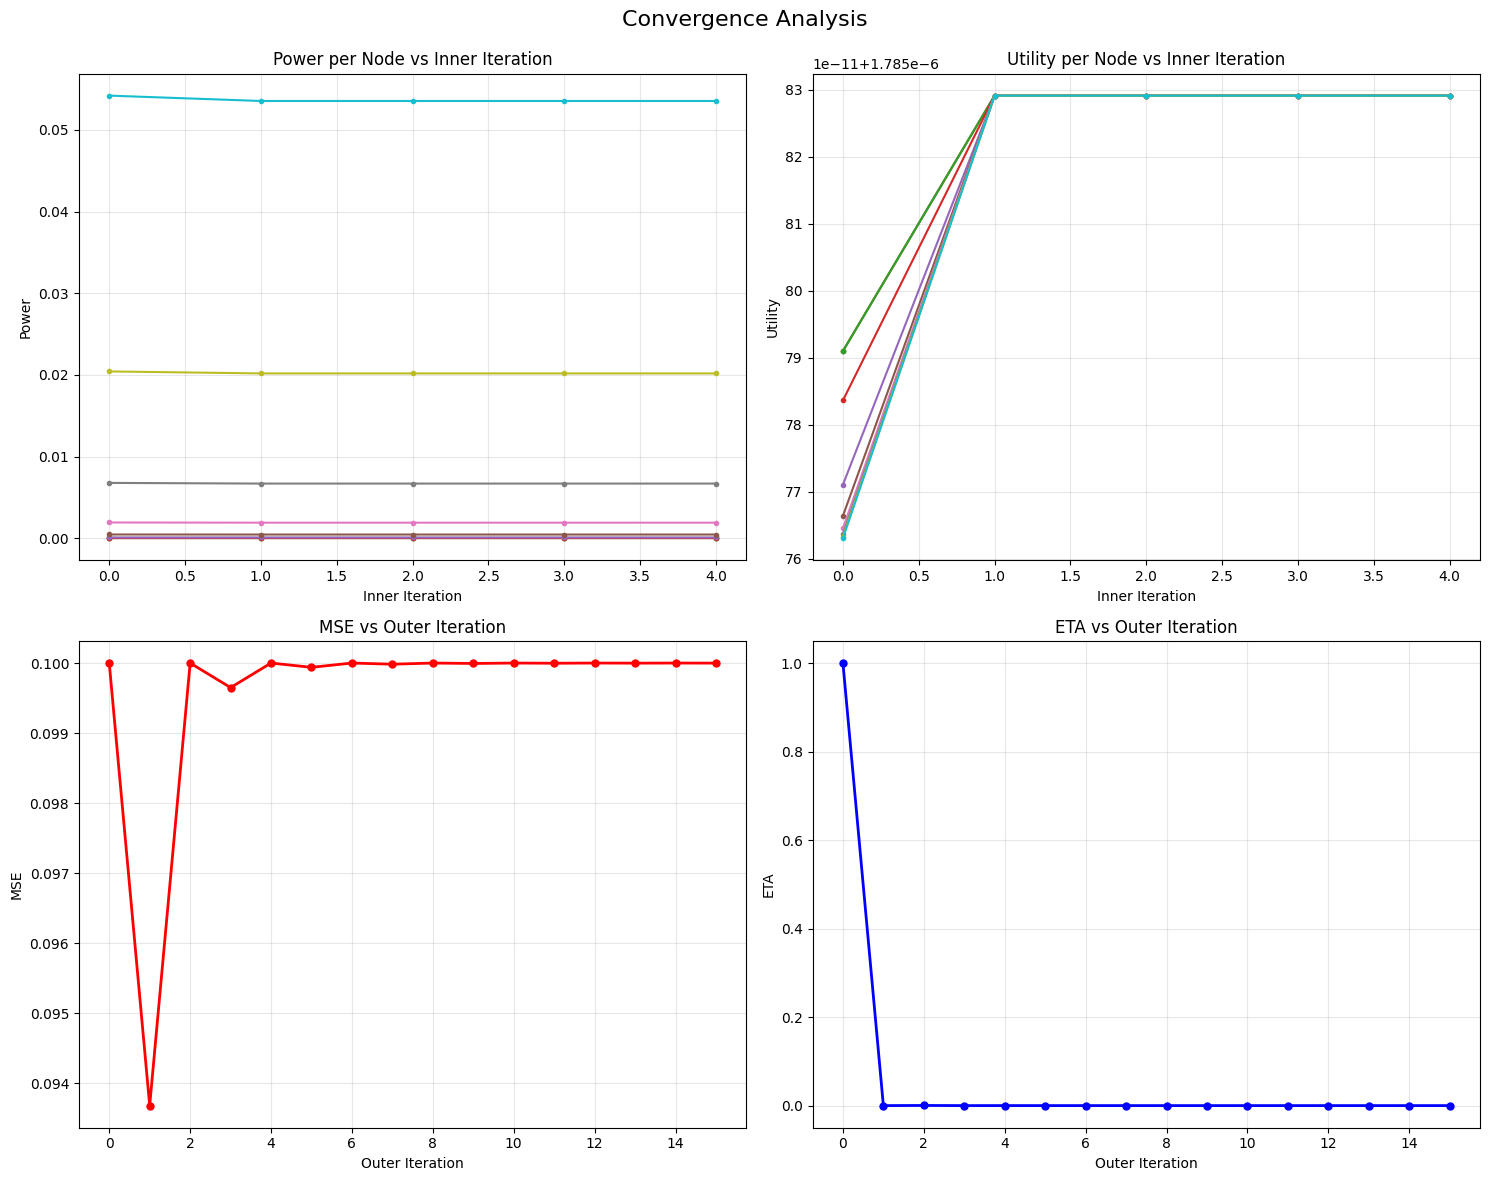

   Node  Final Power P*  Final Utility  Channel Gain h
0     1        0.000003   1.785800e-06    7.902597e-07
1     2        0.000056   1.785800e-06    1.678416e-07
2     3        0.000896   1.785800e-06    4.196411e-08
3     4        0.008984   1.785800e-06    1.325182e-08
4     5        0.063462   1.785800e-06    4.985932e-09
5     6        0.338828   1.785800e-06    2.157813e-09
6     7        1.000000   1.736228e-06    1.046767e-09
7     8        1.000000   1.233823e-06    5.577289e-10
8     9        1.000000   7.963306e-07    3.210889e-10
9    10        1.000000   5.164985e-07    1.971038e-10
Final MSE:  0.09999906706254479
Final ETA:  1.071895022485995e-08
Time taken:  0.039320945739746094
Number of outer iterations:  15
Number of inner iterations:  5


In [9]:
receiver_coordinates = (0.0, 0.0, 0.0)
x_positions = np.linspace(d_max/N, d_max, N)
transmitter_coordinates = [(np.float64(x), 0.0, 0.0) for x in x_positions]
h = np.zeros(N)
for i in range(N):
    h[i] = get_channel_gain(transmitter_coordinates[i],receiver_coordinates,2405*10**6)


#c = np.float64(80022291587.0)
c = np.float64(140000.0)
#c = compute_c_bounds(h, P_max, np.float64(10e-10))
print(c)

start_time = time.time()
df, power_outer_history, utility_outer_history, mse_history, eta_history = adaptive_eta_best_response(
    h=h,
    eta_init=np.float64(1.0),
    epsilon_p=epsilon_p,
    epsilon_mse=epsilon_mse,
    P_max=P_max,
    sigma2=sigma2,
    c=c,
    max_iter=50
)
end_time = time.time()

complexity = end_time - start_time

# Combined plot with all 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Convergence Analysis', fontsize=16)

colors = plt.cm.tab10(np.linspace(0, 1, N))

# Plot 1: Power per node vs inner iteration (last outer iteration)
if len(power_outer_history) > 0:
    power_history = power_outer_history[5]  # Last outer iteration
    ax1 = axes[0, 0]

    for node in range(N):
        node_powers = [power_history[inner_iter][node] for inner_iter in range(len(power_history))]
        ax1.plot(range(len(power_history)), node_powers, 'o-', color=colors[node],
                label=f'Node {node+1}', markersize=3, linewidth=1.5)

    ax1.set_xlabel('Inner Iteration')
    ax1.set_ylabel('Power')
    ax1.set_title('Power per Node vs Inner Iteration')
    #ax1.legend()
    ax1.grid(True, alpha=0.3)

# Plot 2: Utility per node vs inner iteration (last outer iteration)
if len(utility_outer_history) > 0:
    utility_history = utility_outer_history[5]  # Last outer iteration
    ax2 = axes[0, 1]

    for node in range(N):
        node_utilities = [utility_history[inner_iter][node] for inner_iter in range(len(utility_history))]
        ax2.plot(range(len(utility_history)), node_utilities, 'o-', color=colors[node],
                label=f'Node {node+1}', markersize=3, linewidth=1.5)

    ax2.set_xlabel('Inner Iteration')
    ax2.set_ylabel('Utility')
    ax2.set_title('Utility per Node vs Inner Iteration')
    #ax2.legend()
    ax2.grid(True, alpha=0.3)

# Plot 3: MSE vs outer iteration
ax3 = axes[1, 0]
ax3.plot(range(len(mse_history)), mse_history, 'ro-', linewidth=2, markersize=5)
ax3.set_xlabel('Outer Iteration')
ax3.set_ylabel('MSE')
ax3.set_title('MSE vs Outer Iteration')
ax3.grid(True, alpha=0.3)

# Plot 4: ETA vs outer iteration
ax4 = axes[1, 1]
ax4.plot(range(len(eta_history)), eta_history, 'bo-', linewidth=2, markersize=5)
ax4.set_xlabel('Outer Iteration')
ax4.set_ylabel('ETA')
ax4.set_title('ETA vs Outer Iteration')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(df)
print("Final MSE: ", mse_history[-1])
print("Final ETA: ", eta_history[-1])
print("Time taken: ", complexity)
print("Number of outer iterations: ", len(power_outer_history))
print("Number of inner iterations: ", len(power_outer_history[len(power_outer_history)-1]))

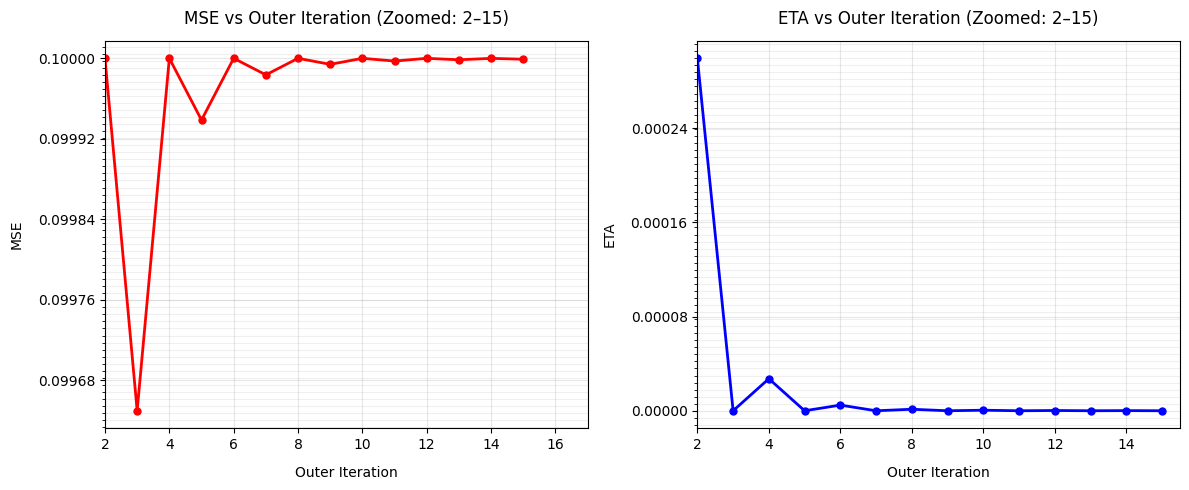

In [10]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, MaxNLocator

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plt.subplots_adjust(left=0.08, right=0.97, top=0.90, bottom=0.12, wspace=0.25)

# ======================
# Plot 1: MSE (zoomed)
# ======================
ax3 = axes[0]
ax3.plot(range(len(mse_history)), mse_history, 'ro-', linewidth=2, markersize=5)
ax3.set_xlabel('Outer Iteration', labelpad=10)
ax3.set_ylabel('MSE', labelpad=10)
ax3.set_title('MSE vs Outer Iteration (Zoomed: 2–15)', pad=12)
ax3.grid(True, alpha=0.3)

# X limits with small right padding
ax3.set_xlim(2, 17)

# Y limits with vertical padding
mse_min, mse_max = min(mse_history[2:16]), max(mse_history[2:16])
padding_ratio = 0.05
y_padding = padding_ratio * (mse_max - mse_min)
ax3.set_ylim(mse_min - y_padding, mse_max + y_padding)

# Major ticks (few labeled ticks)
ax3.yaxis.set_major_locator(MaxNLocator(nbins=5))  # ~5 labeled ticks max

# Minor ticks (high resolution grid only)
ax3.yaxis.set_minor_locator(MultipleLocator((mse_max - mse_min) / 50))  # fine steps for smoother grid
ax3.grid(True, which='minor', alpha=0.2)

# ======================
# Plot 2: ETA (zoomed)
# ======================
ax4 = axes[1]
ax4.plot(range(len(eta_history)), eta_history, 'bo-', linewidth=2, markersize=5)
ax4.set_xlabel('Outer Iteration', labelpad=10)
ax4.set_ylabel('ETA', labelpad=10)
ax4.set_title('ETA vs Outer Iteration (Zoomed: 2–15)', pad=12)
ax4.grid(True, alpha=0.3)

# X limits with small right padding
ax4.set_xlim(2, 15.5)

# Y limits with vertical padding
eta_min, eta_max = min(eta_history[2:16]), max(eta_history[2:16])
padding_ratio = 0.05
y_padding = padding_ratio * (eta_max - eta_min)
ax4.set_ylim(eta_min - y_padding, eta_max + y_padding)

# Major ticks (few labeled)
ax4.yaxis.set_major_locator(MaxNLocator(nbins=5))

# Minor ticks (fine resolution, unlabeled)
ax4.yaxis.set_minor_locator(MultipleLocator((eta_max - eta_min) / 50))
ax4.grid(True, which='minor', alpha=0.2)

plt.tight_layout()
plt.show()


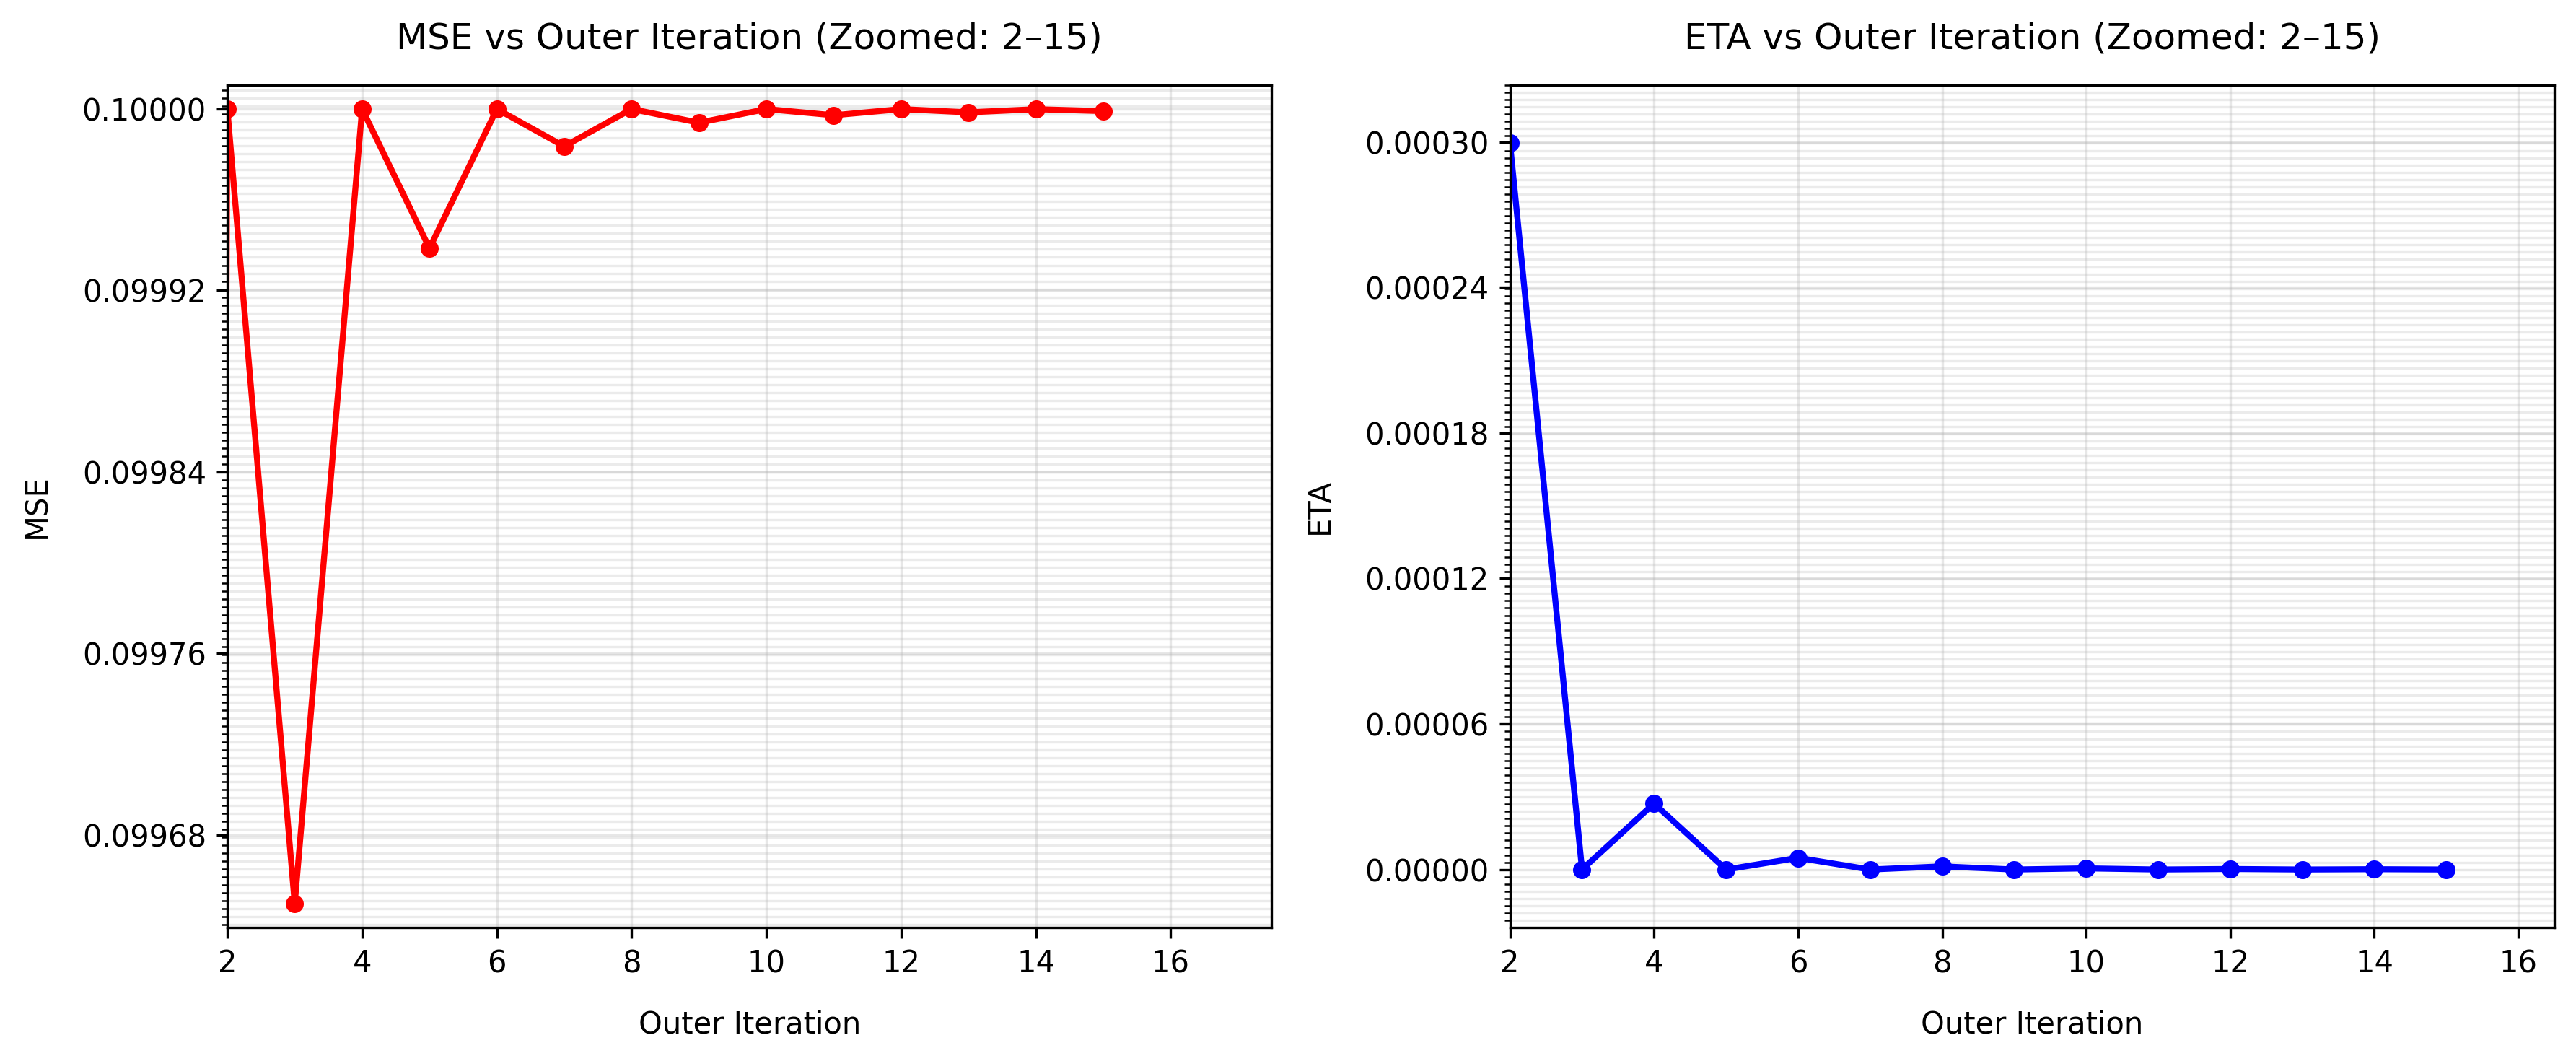

In [11]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, MaxNLocator

fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=300)  # higher resolution
plt.subplots_adjust(left=0.08, right=0.97, top=0.90, bottom=0.12, wspace=0.25)

# ======================
# Plot 1: MSE (zoomed)
# ======================
ax3 = axes[0]
ax3.plot(range(len(mse_history)), mse_history, 'ro-', linewidth=2, markersize=5)
ax3.set_xlabel('Outer Iteration', labelpad=10)
ax3.set_ylabel('MSE', labelpad=10)
ax3.set_title('MSE vs Outer Iteration (Zoomed: 2–15)', pad=12)
ax3.grid(True, alpha=0.3)

# --- X limits with a bit of right padding ---
ax3.set_xlim(2, 17.5)  # extra padding to prevent touching right border

# --- Y limits with slight padding for oscillation visibility ---
mse_min, mse_max = min(mse_history[2:16]), max(mse_history[2:16])
padding_ratio = 0.03  # slightly higher padding for better visual separation
y_padding = padding_ratio * (mse_max - mse_min)
ax3.set_ylim(mse_min - y_padding, mse_max + y_padding)

# --- Major and minor ticks for balanced readability and detail ---
ax3.yaxis.set_major_locator(MaxNLocator(nbins=6))  # ~6 labeled ticks max
ax3.yaxis.set_minor_locator(MultipleLocator((mse_max - mse_min) / 100))  # finer invisible resolution
ax3.grid(True, which='minor', alpha=0.25)

# ======================
# Plot 2: ETA (zoomed)
# ======================
ax4 = axes[1]
ax4.plot(range(len(eta_history)), eta_history, 'bo-', linewidth=2, markersize=5)
ax4.set_xlabel('Outer Iteration', labelpad=10)
ax4.set_ylabel('ETA', labelpad=10)
ax4.set_title('ETA vs Outer Iteration (Zoomed: 2–15)', pad=12)
ax4.grid(True, alpha=0.3)

# --- X limits with padding ---
ax4.set_xlim(2, 16.5)  # right padding for visual space

# --- Y limits with vertical padding ---
eta_min, eta_max = min(eta_history[2:16]), max(eta_history[2:16])
padding_ratio = 0.08
y_padding = padding_ratio * (eta_max - eta_min)
ax4.set_ylim(eta_min - y_padding, eta_max + y_padding)

# --- Major and minor ticks ---
ax4.yaxis.set_major_locator(MaxNLocator(nbins=6))
ax4.yaxis.set_minor_locator(MultipleLocator((eta_max - eta_min) / 100))
ax4.grid(True, which='minor', alpha=0.25)

plt.tight_layout()
plt.show()


In [12]:
power_outer_history[1]

[array([7.12636824e-11, 3.40972154e-09, 6.37282693e-08, 6.62139750e-07,
        4.72547091e-06, 2.53179492e-05, 1.07733845e-04, 3.79724474e-04,
        1.14601735e-03, 3.04171521e-03]),
 array([5.34822884e-11, 1.18562924e-09, 1.89666870e-08, 1.90193792e-07,
        1.34355258e-06, 7.17331612e-06, 3.04822624e-05, 1.07374490e-04,
        3.23963953e-04, 8.59720914e-04]),
 array([5.34793579e-11, 1.18556886e-09, 1.89657397e-08, 1.90184337e-07,
        1.34348588e-06, 7.17296017e-06, 3.04807501e-05, 1.07369164e-04,
        3.23947883e-04, 8.59678268e-04]),
 array([5.34793578e-11, 1.18556886e-09, 1.89657396e-08, 1.90184337e-07,
        1.34348587e-06, 7.17296016e-06, 3.04807501e-05, 1.07369163e-04,
        3.23947882e-04, 8.59678266e-04]),
 array([5.34793578e-11, 1.18556886e-09, 1.89657396e-08, 1.90184337e-07,
        1.34348587e-06, 7.17296016e-06, 3.04807501e-05, 1.07369163e-04,
        3.23947882e-04, 8.59678266e-04])]

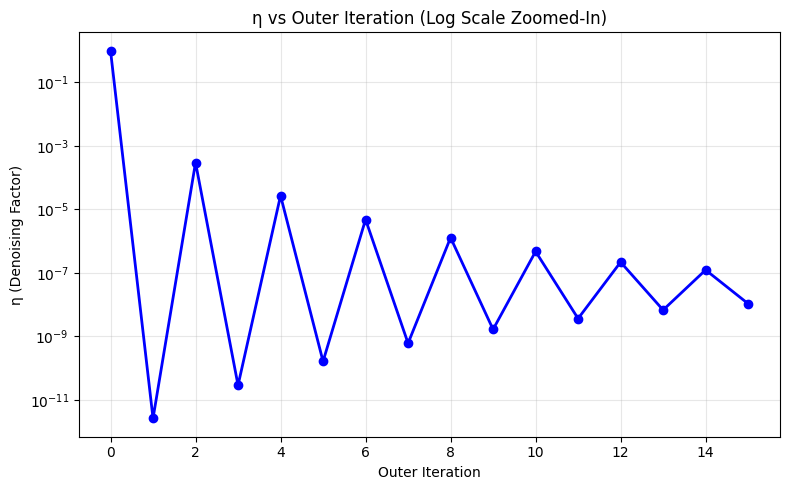

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Assume eta_history is already computed from your algorithm
eta_array = np.array(eta_history)
outer_iters = np.arange(len(eta_array))

plt.figure(figsize=(8, 5))
plt.plot(outer_iters, eta_array, 'bo-', linewidth=2, markersize=6)
plt.xlabel("Outer Iteration")
plt.ylabel("η (Denoising Factor)")
plt.title("η vs Outer Iteration (Zoomed-In)")
plt.grid(True, alpha=0.3)

# ----- ZOOM-IN SETTINGS -----
# Compute small margins around your min and max η
eta_min = np.min(eta_array)
eta_max = np.max(eta_array)
margin = (eta_max - eta_min) * 0.2  # 20% padding

# If all η values are very small, adjust range logarithmically
if eta_max / eta_min < 100:
    plt.ylim(eta_min - margin, eta_max + margin)
else:
    # For wide range, use log scale
    plt.yscale('log')
    plt.title("η vs Outer Iteration (Log Scale Zoomed-In)")

plt.tight_layout()
plt.show()


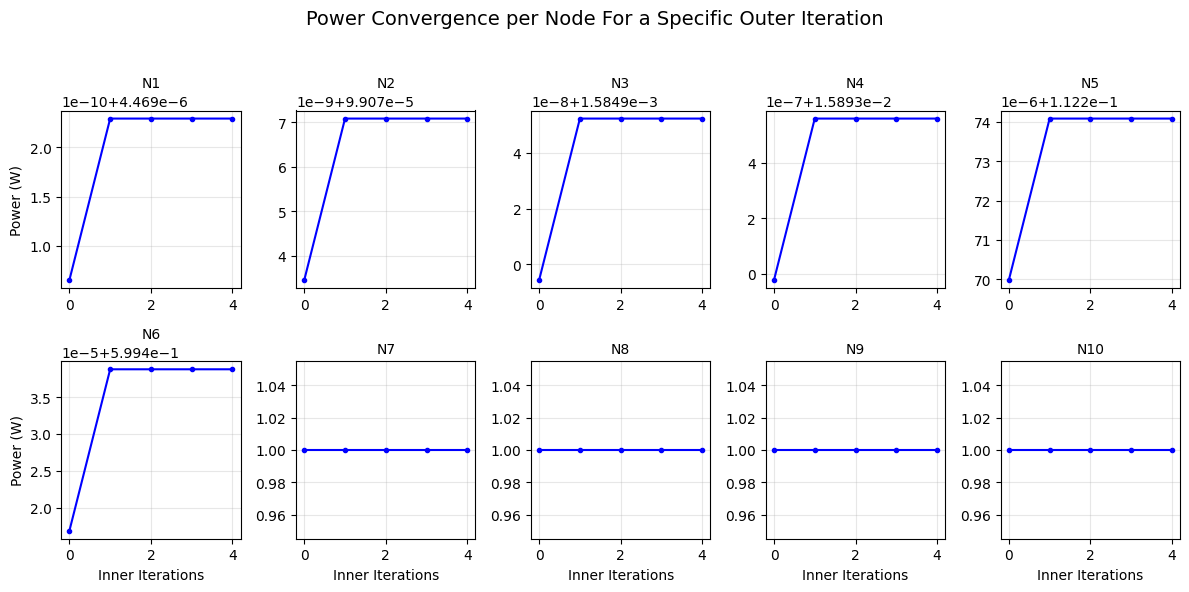

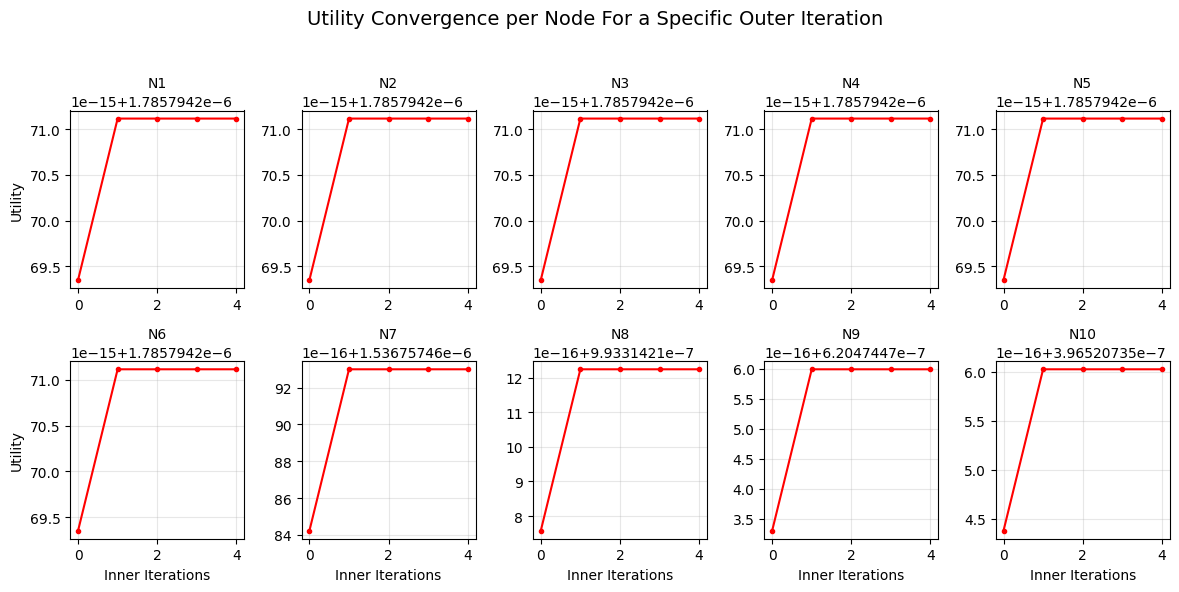

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Choose the last outer iteration (or specify one)
outer_iter_to_plot = 12  # -1 = last outer iteration

# Extract power and utility histories for that outer iteration
power_history = np.array(power_outer_history[outer_iter_to_plot])
utility_history = np.array(utility_outer_history[outer_iter_to_plot])

N = power_history.shape[1]  # number of nodes
inner_iters = np.arange(power_history.shape[0])

# --- Plot Power Convergence per Node ---
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
fig.suptitle("Power Convergence per Node For a Specific Outer Iteration", fontsize=14)

for i, ax in enumerate(axes.flatten()):
    if i < N:
        ax.plot(inner_iters, power_history[:, i], 'b-o', linewidth=1.5, markersize=3)
        ax.set_title(f"N{i+1}", fontsize=10)
        ax.grid(True, alpha=0.3)
    else:
        ax.axis("off")  # hide extra subplots

for ax in axes[:, 0]:
    ax.set_ylabel("Power (W)")
for ax in axes[-1, :]:
    ax.set_xlabel("Inner Iterations")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


# --- Plot Utility Convergence per Node ---
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
fig.suptitle("Utility Convergence per Node For a Specific Outer Iteration", fontsize=14)

for i, ax in enumerate(axes.flatten()):
    if i < N:
        ax.plot(inner_iters, utility_history[:, i], 'r-o', linewidth=1.5, markersize=3)
        ax.set_title(f"N{i+1}", fontsize=10)
        ax.grid(True, alpha=0.3)
    else:
        ax.axis("off")

for ax in axes[:, 0]:
    ax.set_ylabel("Utility")
for ax in axes[-1, :]:
    ax.set_xlabel("Inner Iterations")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


###SCALABILITY

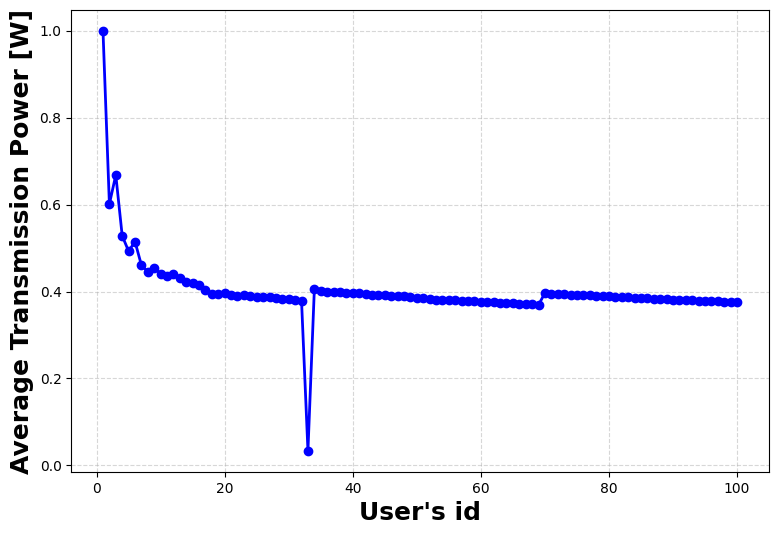

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from google.colab import files

results = []

# Loop over number of transmitters
for i in range(1, 101):   # 1 to 100
    x_positions = np.linspace(d_max/i, d_max, i)
    transmitter_coordinates = [(x, 0.0, 0.0) for x in x_positions]
    h = np.zeros(i)
    for j in range(0, i):
        h[j] = get_channel_gain(transmitter_coordinates[j], receiver_coordinates, 2405e6)

    P = np.random.uniform(0.1, 1.0, i)
    P_max = np.ones(i)

    # Run your algorithm
    df, power_outer_history, utility_outer_history, mse_history, eta_history = adaptive_eta_best_response(h=h,
    eta_init=np.float64(1.0),
    epsilon_p=epsilon_p,
    epsilon_mse=epsilon_mse,
    P_max=P_max,
    sigma2=sigma2,
    c=140000,
    max_iter=50)

    # Extract final powers (example: mean power across transmitters)
    if df is not None:
        mean_power = df['Final Power P*'].mean()
        results.append((i, mean_power))

# Convert to DataFrame for plotting
scalability_df = pd.DataFrame(results, columns=['Users', 'Mean Power'])

# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(scalability_df['Users'], scalability_df['Mean Power'],
        marker='o', color='blue', linewidth=2)

ax.set_xlabel("User's id", fontsize=18, fontweight="bold")
ax.set_ylabel("Average Transmission Power [W]", fontsize=18, fontweight="bold")
ax.grid(True, linestyle="--", alpha=0.5)

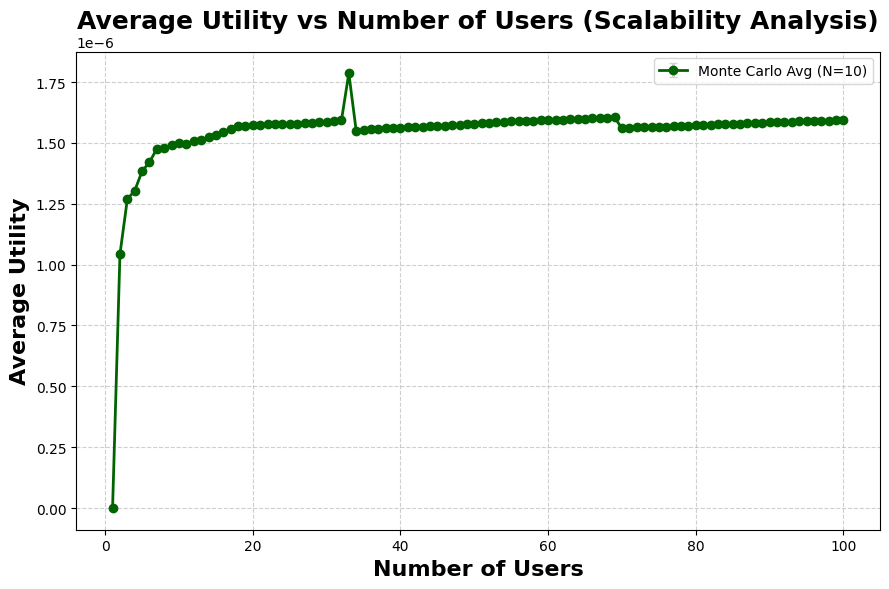

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Parameters
N_MC = 10   # Monte Carlo runs per user count
results_utility = []

# Loop over number of transmitters (users)
for i in range(1, 101):  # 1 to 100 users
    mean_utilities = []

    for mc in range(N_MC):
        # Define transmitter coordinates
        x_positions = np.linspace(d_max/i, d_max, i)
        transmitter_coordinates = [(x, 0.0, 0.0) for x in x_positions]

        # Compute channel gains
        h = np.zeros(i)
        for j in range(i):
            h[j] = get_channel_gain(transmitter_coordinates[j], receiver_coordinates, 2405e6)

        # Random initial powers
        P = np.random.uniform(0.1, 1.0, i)
        P_max = np.ones(i)

        # Run adaptive η-best response algorithm
        df, power_outer_history, utility_outer_history, mse_history, eta_history = adaptive_eta_best_response(
            h=h,
            eta_init=np.float64(1.0),
            epsilon_p=epsilon_p,
            epsilon_mse=epsilon_mse,
            P_max=P_max,
            sigma2=sigma2,
            c=140000,
            max_iter=50
        )

        # Extract mean final utility
        if df is not None and 'Final Utility' in df.columns:
            mean_utilities.append(df['Final Utility'].mean())

    # Average and std deviation over Monte Carlo trials
    if len(mean_utilities) > 0:
        avg_mean_utility = np.mean(mean_utilities)
        std_utility = np.std(mean_utilities)
        results_utility.append((i, avg_mean_utility, std_utility))

# Convert to DataFrame for plotting
utility_df = pd.DataFrame(results_utility, columns=['Users', 'Mean Utility', 'Std Utility'])

# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 6))

ax.errorbar(
    utility_df['Users'],
    utility_df['Mean Utility'],
    yerr=utility_df['Std Utility'],
    marker='o',
    color='darkgreen',
    ecolor='lightgray',
    elinewidth=2,
    capsize=3,
    linewidth=2,
    label=f'Monte Carlo Avg (N={N_MC})'
)

ax.set_xlabel("Number of Users", fontsize=16, fontweight="bold")
ax.set_ylabel("Average Utility", fontsize=16, fontweight="bold")
ax.set_title("Average Utility vs Number of Users (Scalability Analysis)", fontsize=18, fontweight="bold")
ax.grid(True, linestyle="--", alpha=0.6)
ax.legend()

plt.tight_layout()
plt.show()


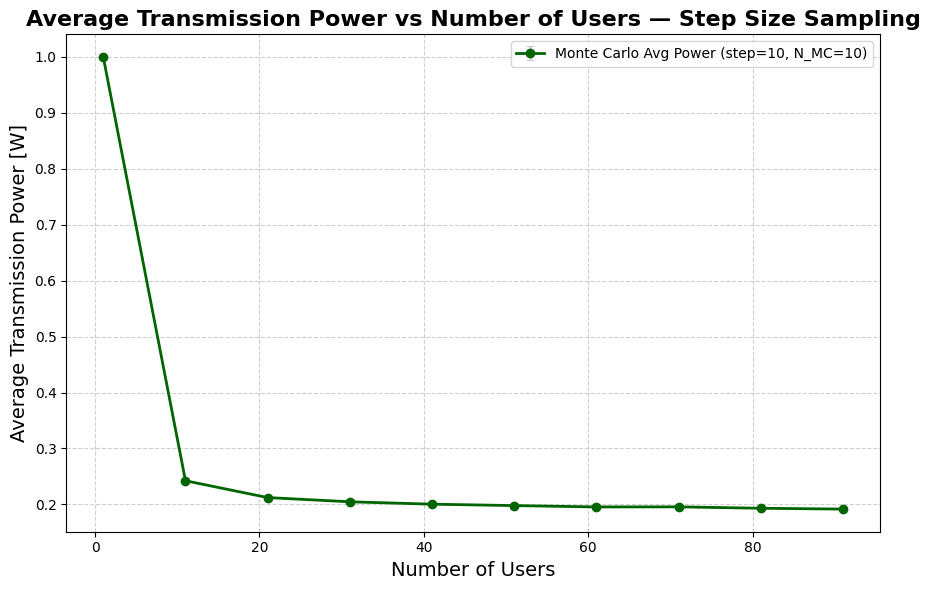

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ======= Experiment Parameters =======
N_MC = 10           # Monte Carlo runs per user count
max_users = 100     # up to 100 users
step = 10           # step size for sampling (change to 2, 5, etc.)
sigma2 = 1e-13
d_max = 100.0

receiver_coordinates = (0.0, 0.0, 0.0)

epsilon_p = 1e-15
epsilon_mse = 1e-6

# ======= Monte Carlo Simulation for Average Power =======
results_power = []

for n_users in range(1, max_users + 1):
    avg_powers = []
    for mc in range(N_MC):
        # Transmitter coordinates
        x_positions = np.linspace(d_max / n_users, d_max, n_users)
        tx_coords = [(x, 0.0, 0.0) for x in x_positions]

        # Channel gains
        h = np.array([get_channel_gain(tx, receiver_coordinates, 2405e6) for tx in tx_coords])
        P_max = np.ones(n_users)

        # Run distributed optimization
        df, power_outer_history, utility_outer_history, mse_history, eta_history = adaptive_eta_best_response(
            h=h,
            eta_init=1.0,
            epsilon_p=epsilon_p,
            epsilon_mse=epsilon_mse,
            P_max=P_max,
            sigma2=sigma2,
            c=140000.0,
            max_iter=50
        )

        # Extract final average power (if available)
        if power_outer_history is not None:
            # Assuming power_outer_history is a list/array of per-user powers
            final_powers = np.array(power_outer_history[-1])  # last iteration
            avg_powers.append(np.mean(final_powers))

    # Average and std deviation over Monte Carlo runs
    if avg_powers:
        results_power.append((n_users, np.mean(avg_powers), np.std(avg_powers)))

# Convert to DataFrame
power_df = pd.DataFrame(results_power, columns=['Users', 'Mean Power', 'Std Power'])

# ======= Step-Size Sampling =======
users_step = power_df['Users'][::step]
mean_power_step = power_df['Mean Power'][::step]
std_power_step = power_df['Std Power'][::step]

# ======= Plot =======
plt.figure(figsize=(9, 6))
plt.errorbar(
    users_step, mean_power_step, yerr=std_power_step,
    marker='o', color='darkgreen', ecolor='lightgray',
    elinewidth=2, capsize=3, linewidth=2,
    label=f'Monte Carlo Avg Power (step={step}, N_MC={N_MC})'
)
plt.title('Average Transmission Power vs Number of Users — Step Size Sampling', fontsize=16, fontweight='bold')
plt.xlabel('Number of Users', fontsize=14)
plt.ylabel('Average Transmission Power [W]', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


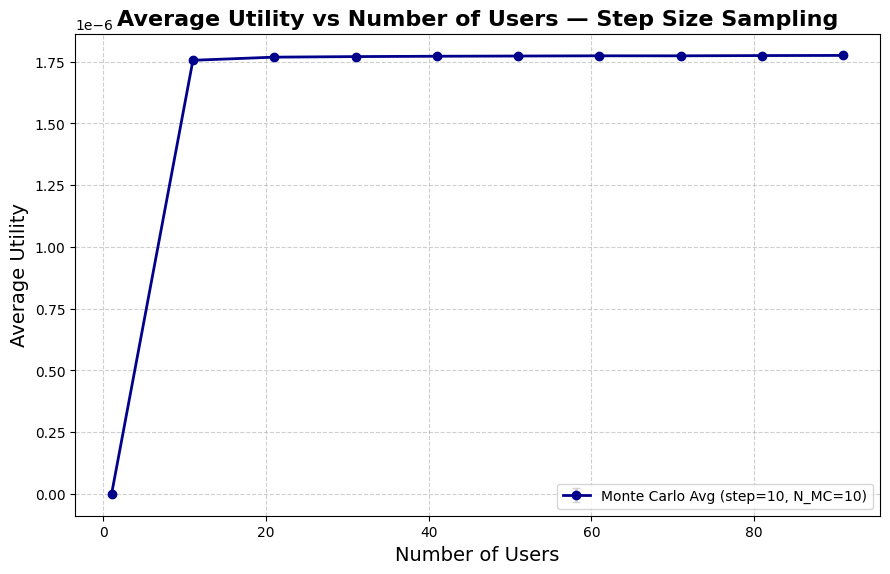

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ======= Experiment Parameters =======
N_MC = 10           # Monte Carlo runs per user count
max_users = 100     # up to 100 users
step = 10           # step size for sampling (change to 2, 5, etc.)
sigma2 = 1e-13
d_max = 100.0

receiver_coordinates = (0.0, 0.0, 0.0)

epsilon_p = 1e-15
epsilon_mse = 1e-6

# ======= Monte Carlo Simulation =======
results = []

for n_users in range(1, max_users + 1):
    utilities = []
    for mc in range(N_MC):
        x_positions = np.linspace(d_max / n_users, d_max, n_users)
        tx_coords = [(x, 0.0, 0.0) for x in x_positions]
        h = np.array([get_channel_gain(tx, receiver_coordinates, 2405e6) for tx in tx_coords])
        P_max = np.ones(n_users)

        df, *_ = adaptive_eta_best_response(
            h=h,
            eta_init=1.0,
            epsilon_p=epsilon_p,
            epsilon_mse=epsilon_mse,
            P_max=P_max,
            sigma2=sigma2,
            c=140000.0,
            max_iter=50
        )
        if df is not None and 'Final Utility' in df.columns:
            utilities.append(df['Final Utility'].mean())

    if utilities:
        results.append((n_users, np.mean(utilities), np.std(utilities)))

# Convert results to DataFrame
utility_df = pd.DataFrame(results, columns=['Users', 'Mean Utility', 'Std Utility'])

# ======= Step-Size Sampling =======
users_step = utility_df['Users'][::step]
mean_step = utility_df['Mean Utility'][::step]
std_step = utility_df['Std Utility'][::step]

# ======= Plot =======
plt.figure(figsize=(9, 6))
plt.errorbar(
    users_step, mean_step, yerr=std_step,
    marker='o', color='darkblue', ecolor='lightgray',
    elinewidth=2, capsize=3, linewidth=2,
    label=f'Monte Carlo Avg (step={step}, N_MC={N_MC})'
)
plt.title('Average Utility vs Number of Users — Step Size Sampling', fontsize=16, fontweight='bold')
plt.xlabel('Number of Users', fontsize=14)
plt.ylabel('Average Utility', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


AVERAGE MSE VS NUMBER OF USERS

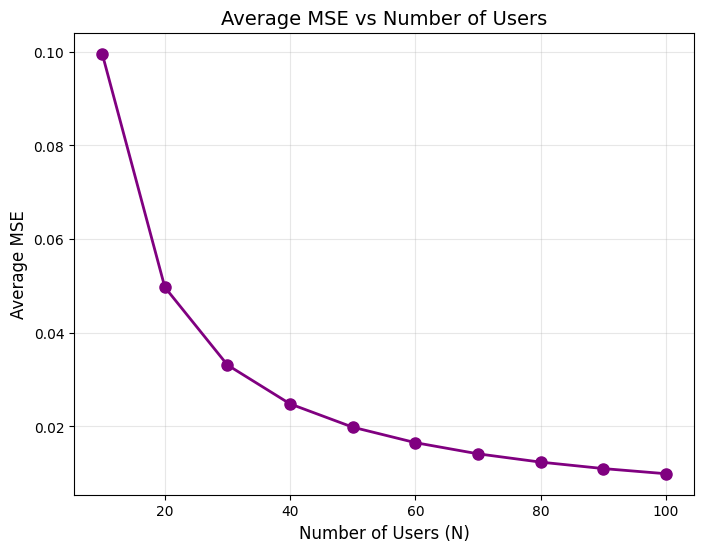

In [19]:
N_values = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
avg_mse_values = []

for N in N_values:
    epsilon_p = 1e-15
    epsilon_mse = 1e-6
    sigma2 = 10e-13
    EXP_POWER_UTILITY = 1
    d_max = 100.0
    P_max = np.ones(N).astype(np.float64)

    receiver_coordinates = (0.0, 0.0, 0.0)
    x_positions = np.linspace(d_max / N, d_max, N)
    transmitter_coordinates = [(np.float64(x), 0.0, 0.0) for x in x_positions]
    h = np.zeros(N)
    for i in range(N):
        h[i] = get_channel_gain(transmitter_coordinates[i], receiver_coordinates, 2405 * 10**6)

    c = np.float64(140000.0)

    _, _, _, mse_history, _ = adaptive_eta_best_response(
        h=h,
        eta_init=np.float64(1.0),
        epsilon_p=epsilon_p,
        epsilon_mse=epsilon_mse,
        P_max=P_max,
        sigma2=sigma2,
        c=c,
        max_iter=50
    )

    avg_mse = np.mean(mse_history)
    avg_mse_values.append(avg_mse)

# Plot Average MSE vs Number of Users
plt.figure(figsize=(8, 6))
plt.plot(N_values, avg_mse_values, 'o-', color='purple', linewidth=2, markersize=8)
plt.xlabel('Number of Users (N)', fontsize=12)
plt.ylabel('Average MSE', fontsize=12)
plt.title('Average MSE vs Number of Users', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()


TIME OF STACKELBERG VS NUMBER OF USERS

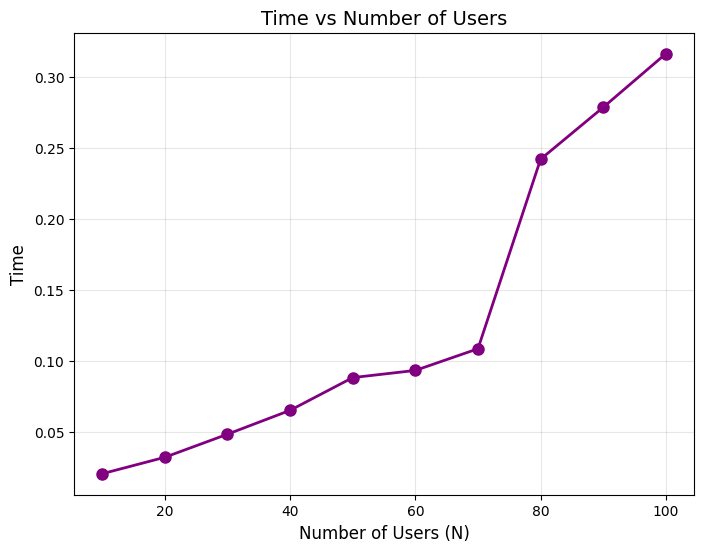

In [20]:
N_values = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
time_values = []


for N in N_values:
    epsilon_p = 1e-15
    epsilon_mse = 1e-6
    sigma2 = 10e-13
    EXP_POWER_UTILITY = 1
    d_max = 100.0
    P_max = np.ones(N).astype(np.float64)

    receiver_coordinates = (0.0, 0.0, 0.0)
    x_positions = np.linspace(d_max / N, d_max, N)
    transmitter_coordinates = [(np.float64(x), 0.0, 0.0) for x in x_positions]
    h = np.zeros(N)
    for i in range(N):
        h[i] = get_channel_gain(transmitter_coordinates[i], receiver_coordinates, 2405 * 10**6)

    c = np.float64(200000.0)

    start_time = time.time()
    df, power_outer_history, utility_outer_history, mse_history, eta_history = adaptive_eta_best_response(
    h=h,
    eta_init=np.float64(1.0),
    epsilon_p=epsilon_p,
    epsilon_mse=epsilon_mse,
    P_max=P_max,
    sigma2=sigma2,
    c=c,
    max_iter=50
    )
    end_time = time.time()
    complexity = end_time - start_time
    time_values.append(complexity)

# Plot time vs Number of Users
plt.figure(figsize=(8, 6))
plt.plot(N_values, time_values, 'o-', color='purple', linewidth=2, markersize=8)
plt.xlabel('Number of Users (N)', fontsize=12)
plt.ylabel('Time', fontsize=12)
plt.title('Time vs Number of Users', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

TIME OF STACKELBERG VS NUMBER OF USERS - MONTE CARLO

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

# Monte Carlo settings
num_trials = 100  # number of Monte Carlo iterations per N
N_values = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
avg_time_values = []

for N in N_values:
    epsilon_p = 1e-15
    epsilon_mse = 1e-6
    sigma2 = 10e-13
    EXP_POWER_UTILITY = 1
    d_max = 100.0
    P_max = np.ones(N).astype(np.float64)
    c = np.float64(140000.0)

    # Store runtimes for each Monte Carlo trial
    monte_carlo_times = []

    for trial in range(num_trials):
        # Randomize transmitter positions slightly in each trial (optional)
        receiver_coordinates = (0.0, 0.0, 0.0)
        x_positions = np.linspace(d_max / N, d_max, N)
        transmitter_coordinates = [(np.float64(x), 0.0, 0.0) for x in x_positions]

        # Channel gains
        h = np.zeros(N)
        for i in range(N):
            h[i] = get_channel_gain(
                transmitter_coordinates[i],
                receiver_coordinates,
                2405 * 10**6
            )

        # Measure runtime
        start_time = time.time()
        df, power_outer_history, utility_outer_history, mse_history, eta_history = adaptive_eta_best_response(
            h=h,
            eta_init=np.float64(1.0),
            epsilon_p=epsilon_p,
            epsilon_mse=epsilon_mse,
            P_max=P_max,
            sigma2=sigma2,
            c=c,
            max_iter=50
        )
        end_time = time.time()

        monte_carlo_times.append(end_time - start_time)

    # Average runtime for this N
    avg_time = np.mean(monte_carlo_times)
    avg_time_values.append(avg_time)
    print(f"N={N}, Average Time={avg_time:.4f} seconds")

# Plot averaged time vs number of users
plt.figure(figsize=(8, 6))
plt.plot(N_values, avg_time_values, 'o-', color='purple', linewidth=2, markersize=8)
plt.xlabel('Number of Users (N)', fontsize=12)
plt.ylabel('Average Runtime (s)', fontsize=12)
plt.title('Average Runtime vs Number of Users (Monte Carlo Averaged)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()


### INDOOR OUTDOOR

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

# Monte Carlo settings
num_trials = 1
N_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

eta_indoor_avg = []
eta_outdoor_avg = []

for N in N_values:
    epsilon_p = 1e-15
    epsilon_mse = 1e-6
    sigma2 = 10e-13
    EXP_POWER_UTILITY = 1
    d_max = 100.0
    P_max = np.ones(N).astype(np.float64)
    c = np.float64(140000.0)
    receiver_coordinates = (0.0, 0.0, 0.0)
    x_positions = np.linspace(d_max / N, d_max, N)
    transmitter_coordinates = [(np.float64(x), 0.0, 0.0) for x in x_positions]

    eta_indoor_trials = []
    eta_outdoor_trials = []

    for trial in range(num_trials):
        # --- Indoor Channel ---
        h_indoor = np.zeros(N)
        for i in range(N):
            h_indoor[i] = get_channel_gain_InH(
                transmitter_coordinates[i],
                receiver_coordinates,
                2405 * 10**6
            )

        _, _, _, _, eta_history_in = adaptive_eta_best_response(
            h=h_indoor,
            eta_init=np.float64(1.0),
            epsilon_p=epsilon_p,
            epsilon_mse=epsilon_mse,
            P_max=P_max,
            sigma2=sigma2,
            c=c,
            max_iter=50
        )
        eta_indoor_trials.append(eta_history_in[-1])

        # --- Outdoor Channel ---
        h_outdoor = np.zeros(N)
        for i in range(N):
            h_outdoor[i] = get_channel_gain(
                transmitter_coordinates[i],
                receiver_coordinates,
                2405 * 10**6
            )

        _, _, _, _, eta_history_out = adaptive_eta_best_response(
            h=h_outdoor,
            eta_init=np.float64(1.0),
            epsilon_p=epsilon_p,
            epsilon_mse=epsilon_mse,
            P_max=P_max,
            sigma2=sigma2,
            c=c,
            max_iter=50
        )
        eta_outdoor_trials.append(eta_history_out[-1])

    # Take Monte Carlo averages
    eta_indoor_avg.append(np.mean(eta_indoor_trials))
    eta_outdoor_avg.append(np.mean(eta_outdoor_trials))

    print(f"N={N}: Indoor η = {eta_indoor_avg[-1]:.12f}, Outdoor η = {eta_outdoor_avg[-1]:.12f}")

# --- Plot ---
plt.figure(figsize=(8, 6))
plt.plot(N_values, eta_indoor_avg, 'o-', color='blue', linewidth=2, markersize=8, label='Indoor Channel')
plt.plot(N_values, eta_outdoor_avg, 's--', color='orange', linewidth=2, markersize=8, label='Outdoor Channel')
plt.xlabel('Number of Users (N)', fontsize=12)
plt.ylabel('η (Eta)', fontsize=12)
plt.title('Eta vs Number of Users (Indoor vs Outdoor)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.show()


In [ ]:
# --- Plot ---
plt.figure(figsize=(8, 6))
plt.plot(N_values, eta_indoor_avg, 'o-', color='blue', linewidth=2, markersize=8, label='Indoor Channel')
plt.plot(N_values, eta_outdoor_avg, 's--', color='orange', linewidth=2, markersize=8, label='Outdoor Channel')
plt.xlabel('Number of Users (N)', fontsize=12)
plt.ylabel(' η (Eta)', fontsize=12)
plt.title('Eta vs Number of Users (Indoor vs Outdoor)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)

# Zoom in on N = 2 to 10 and Y range where values are small
plt.xlim(2, 10)
plt.ylim(0, max(max(eta_indoor_avg[1:]), max(eta_outdoor_avg[1:])) * 1.2)

plt.show()


###POWER- INDOOR VS OUTDOOR

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
N = 10
epsilon_p = 1e-15
epsilon_mse = 1e-6
sigma2 = 10e-13
EXP_POWER_UTILITY = 1   # affects utility shaping
d_max = 100.0
P_max = np.ones(N).astype(np.float64)
c = np.float64(140000.0)

# --- Coordinates ---
receiver_coordinates = (0.0, 0.0, 0.0)
x_positions = np.linspace(d_max / N, d_max, N)
transmitter_coordinates = [(np.float64(x), 0.0, 0.0) for x in x_positions]

# --- Channel Gains (Outdoor) ---
h_outdoor = np.zeros(N)
for i in range(N):
    h_outdoor[i] = get_channel_gain(transmitter_coordinates[i], receiver_coordinates, 2405 * 10**6)

# --- Channel Gains (Indoor) ---
h_indoor = np.zeros(N)
for i in range(N):
    h_indoor[i] = get_channel_gain_InH(transmitter_coordinates[i], receiver_coordinates, 2405 * 10**6)

# --- Adaptive Best Response ---
df_outdoor, _, _, _, _ = adaptive_eta_best_response(
    h=h_outdoor,
    eta_init=np.float64(1.0),
    epsilon_p=epsilon_p,
    epsilon_mse=epsilon_mse,
    P_max=P_max,
    sigma2=sigma2,
    c=c,
    max_iter=50
)

df_indoor, _, _, _, _ = adaptive_eta_best_response(
    h=h_indoor,
    eta_init=np.float64(1.0),
    epsilon_p=epsilon_p,
    epsilon_mse=epsilon_mse,
    P_max=P_max,
    sigma2=sigma2,
    c=c,
    max_iter=50
)

# --- Extract Per-User Final Power ---
power_outdoor = df_outdoor["Final Power P*"].values
power_indoor = df_indoor["Final Power P*"].values

# --- Print Results ---
print("\nOutdoor Channel Final Powers:")
print(power_outdoor)
print("\nIndoor Channel Final Powers:")
print(power_indoor)

# --- Plot ---
plt.figure(figsize=(8, 6))
plt.plot(range(1, N + 1), power_outdoor, 's--', color='blue', linewidth=2, markersize=8, label='Outdoor Channel')
plt.plot(range(1, N + 1), power_indoor, 'o-', color='orange', linewidth=2, markersize=8, label='Indoor Channel')
plt.xlabel('User Index', fontsize=12)
plt.ylabel('Final Power $P^*$', fontsize=12)
plt.title(f'Per-User Final Power for N = {N}', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.show()


###CENTRALISED UTILITY SOLUTION--MAX UTILITY


In [ ]:
from scipy.optimize import minimize
import numpy as np

def centralized_utility_solution_joint(h, c, P_max, eta_bounds=(1e-20, 1e20)):
    """
    Jointly maximizes total utility over P and eta.
    """
    n = len(h)

    # Objective: maximize sum of utilities (we minimize its negative)
    def objective(x):
        P = x[:n]
        eta = x[-1]
        utility = utility_vector(P, h, c, eta)
        return -np.sum(utility)

    # Bounds for each P_i and eta
    bounds = [(0, P_max[i]) for i in range(n)] + [eta_bounds]

    # Initial guess: half of max power and eta=1
    x0 = np.concatenate([np.array(P_max) / 2, [1.0]])

    # Optimization using L-BFGS-B
    res = minimize(objective, x0, bounds=bounds, method="L-BFGS-B")

    # Extract results
    P_opt = res.x[:n]
    eta_opt = res.x[-1]

    return P_opt, eta_opt, res



###MIN MSE SOLUTION



In [ ]:
def centralized_mse_solution(h, eta, P_max):
    N = len(h)

    optimal_P = np.zeros(N)
    # The calculation of optimal_P should use the scalar eta
    optimal_P = eta / (h ** 2)

    optimal_P = np.clip(optimal_P, np.zeros(N), P_max)
    return optimal_P

###MIN MSE SOLUTION - OPTIMIZATION VERSION

In [ ]:
from scipy.optimize import minimize
import numpy as np

def centralized_mse_solution_joint(h, P_max, eta_bounds=(1e-20, 1e20)):
    """
    Jointly minimize total MSE over P and eta.
    MSE = sum_i (P_i * h_i^2 - eta)^2
    """
    h = np.array(h, dtype=np.float64)
    n = len(h)

    # Objective: minimize sum of squared errors
    def objective(x):
        P = x[:n]
        eta = x[-1]
        mse_terms = (P * (h**2) - eta)**2
        return np.sum(mse_terms)

    # Bounds for each P_i and eta
    bounds = [(0, P_max[i]) for i in range(n)] + [eta_bounds]

    # Initial guess: P = half max power, eta = average scaled value
    eta_init = np.mean((np.array(P_max)/2) * (h**2))
    x0 = np.concatenate([np.array(P_max)/2, [eta_init]])

    # Optimization (L-BFGS-B handles box constraints smoothly)
    res = minimize(objective, x0, bounds=bounds, method="L-BFGS-B")

    # Extract results
    P_opt = res.x[:n]
    eta_opt = res.x[-1]

    return P_opt, eta_opt, res


###MSE FOR ALL THREE METHODS

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize



# ============ Main Experiment ============

N_values = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
avg_mse_distributed = []
avg_mse_centralized = []
avg_mse_min_mse = []

epsilon_p = 1e-15
epsilon_mse = 1e-6
sigma2 = 10e-13
EXP_POWER_UTILITY = 1
d_max = 100.0
c = np.float64(140000.0)

for N in N_values:
    print(f"\n===== Running for N = {N} users ===((")
    P_max = np.ones(N).astype(np.float64)

    receiver_coordinates = (0.0, 0.0, 0.0)
    x_positions = np.linspace(d_max / N, d_max, N)
    transmitter_coordinates = [(float(x), 0.0, 0.0) for x in x_positions]

    # Channel gains
    h = np.zeros(N)
    for i in range(N):
        h[i] = get_channel_gain(transmitter_coordinates[i], receiver_coordinates, 2405e6)

    # --- Distributed (Adaptive η) ---
    _, _, _, mse_history, eta_history = adaptive_eta_best_response(
        h=h,
        eta_init=np.float64(1.0),
        epsilon_p=epsilon_p,
        epsilon_mse=epsilon_mse,
        P_max=P_max,
        sigma2=sigma2,
        c=c,
        max_iter=50
    )
    avg_mse_distributed.append(np.mean(mse_history))

    # --- Centralized (Max Utility) ---
    P_opt_central, eta_opt_central, res = centralized_utility_solution_joint(h, c, P_max)
    # Compute theoretical MSE = average power deviation
    # Re-calculate eta based on P_opt_central and sigma2
    eta_central = optimal_eta(h, P_opt_central, sigma2)
    mse_centralized = mse(P_opt_central, h, eta_central, sigma2)
    avg_mse_centralized.append(mse_centralized)

    # --- Centralized (Min MSE) ---
    # Correctly unpack the result from centralized_mse_solution_joint
    P_min_mse_opt_val, eta_min_mse_opt_val, _ = centralized_mse_solution_joint(h, P_max, eta_bounds=(1e-20, 1e20))
    # Use the optimized power values and the corresponding optimal eta from the Min MSE solution
    mse_min_mse_val = mse(P_min_mse_opt_val, h, eta_min_mse_opt_val, sigma2)
    avg_mse_min_mse.append(mse_min_mse_val)


# ============ Plot MSE vs Number of Users ============
plt.figure(figsize=(9, 6))
plt.plot(N_values, avg_mse_distributed, 'o-', color='tab:blue', linewidth=2, markersize=8, label='Distributed (Adaptive)')
plt.plot(N_values, avg_mse_centralized, 's-', color='tab:orange', linewidth=2, markersize=8, label='Centralized (Max Utility)')
plt.plot(N_values, avg_mse_min_mse, '^--', color='tab:green', linewidth=2, markersize=8, label='Centralized (Min MSE)')

plt.xlabel('Number of Users (N)', fontsize=14, fontweight='bold')
plt.ylabel('Average MSE', fontsize=14, fontweight='bold')
plt.title('Average MSE vs Number of Users', fontsize=16, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

###AVERAGE TRANSMISSION POWER FOR ALL THREE METHODS

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ===================== Your existing functions should be defined here =====================
# You should have definitions for:
# get_channel_gain(), adaptive_eta_best_response(), centralized_utility_solution_joint(),
# optimal_eta(), mse(), centralized_mse_solution()
# =================================================================================================

# ============ Main Experiment ============

N_values = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
avg_power_distributed = []
avg_power_centralized = []
avg_power_min_mse = []

epsilon_p = 1e-15
epsilon_mse = 1e-6
sigma2 = 10e-13
EXP_POWER_UTILITY = 1
d_max = 100.0
c = np.float64(140000.0)

for N in N_values:
    print(f"\n===== Running for N = {N} users =====")
    P_max = np.ones(N).astype(np.float64)

    receiver_coordinates = (0.0, 0.0, 0.0)
    x_positions = np.linspace(d_max / N, d_max, N)
    transmitter_coordinates = [(float(x), 0.0, 0.0) for x in x_positions]

    # Channel gains
    h = np.zeros(N)
    for i in range(N):
        h[i] = get_channel_gain(transmitter_coordinates[i], receiver_coordinates, 2405e6)

    # --- Distributed (Adaptive η) ---
    P_distributed_df, power_outer_history, utility_outer_history, mse_history, eta_history = adaptive_eta_best_response(
        h=h,
        eta_init=np.float64(1.0),
        epsilon_p=epsilon_p,
        epsilon_mse=epsilon_mse,
        P_max=P_max,
        sigma2=sigma2,
        c=c,
        max_iter=50
    )
    # Extract the numpy array from the DataFrame column
    P_distributed = P_distributed_df['Final Power P*'].values
    avg_power_distributed.append(np.mean(P_distributed))

    # --- Centralized (Max Utility) ---
    P_opt_central, eta_opt_central, res = centralized_utility_solution_joint(h, c, P_max)
    avg_power_centralized.append(np.mean(P_opt_central))

    # --- Centralized (Min MSE) ---
    # Ensure P_max and h are treated as 1D arrays before calculation
    #eta_mse = 1.2624723277994062e-10
    P_mse, _, _ = centralized_mse_solution_joint(h,P_max,eta_bounds=(1e-20, 1e20))
    avg_power_min_mse.append(np.mean(P_mse))


# ============ Plot Average Transmission Power vs User's ID ============

user_ids = N_values

plt.figure(figsize=(5, 3))
plt.plot(user_ids, avg_power_distributed, 'o-', label='Distributed', color='tab:blue')
plt.plot(user_ids, avg_power_centralized, 's-', label='Max Sum Utility', color='tab:orange')
plt.plot(user_ids, avg_power_min_mse, '-', label='Min MSE', color='tab:green')

plt.xlabel("Number of Users (N)", fontsize=11)
plt.ylabel('Average Transmission Power [W]', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(0, 1.05)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

###COMPUTATION TIME - THREE DIFFERENT METHODS

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

# ===================== Your existing functions should be defined here =====================
# You should have definitions for:
# get_channel_gain(), adaptive_eta_best_response(), centralized_utility_solution_joint(),
# optimal_eta(), mse(), centralized_mse_solution()
# =================================================================================================

# ============ Main Experiment ============

N_values = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

# Average transmission power storage (optional if you still want it)
avg_power_distributed = []
avg_power_centralized = []
avg_power_min_mse = []

# --- New: Execution time storage ---
time_distributed = []
time_centralized = []
time_min_mse = []

epsilon_p = 1e-15
epsilon_mse = 1e-6
sigma2 = 10e-13
d_max = 100.0
c = np.float64(140000.0)

for N in N_values:
    print(f"\n===== Running for N = {N} users ====")
    P_max = np.ones(N).astype(np.float64)

    receiver_coordinates = (0.0, 0.0, 0.0)
    x_positions = np.linspace(d_max / N, d_max, N)
    transmitter_coordinates = [(float(x), 0.0, 0.0) for x in x_positions]

    # Channel gains
    h = np.zeros(N)
    for i in range(N):
        h[i] = get_channel_gain(transmitter_coordinates[i], receiver_coordinates, 2405e6)

    # --- Distributed (Adaptive η) ---
    t0 = time.time()
    P_distributed_df, power_outer_history, utility_outer_history, mse_history, eta_history = adaptive_eta_best_response(
        h=h,
        eta_init=np.float64(1.0),
        epsilon_p=epsilon_p,
        epsilon_mse=epsilon_mse,
        P_max=P_max,
        sigma2=sigma2,
        c=c,
        max_iter=50
    )
    t_distributed = time.time() - t0
    time_distributed.append(t_distributed/N)

    P_distributed = P_distributed_df['Final Power P*'].values
    avg_power_distributed.append(np.mean(P_distributed))

    # --- Centralized (Max Utility) ---
    t0 = time.time()
    P_opt_central, eta_opt_central, res = centralized_utility_solution_joint(h, c, P_max)
    t_centralized = time.time() - t0
    time_centralized.append(t_centralized)

    avg_power_centralized.append(np.mean(P_opt_central))

    # --- Centralized (Min MSE) ---
    # eta_mse = 1.2624723277994062e-10 # This eta value is hardcoded, consider using dynamic calculation if needed
    t0 = time.time()
    P_mse_opt, eta_mse, _ = centralized_mse_solution_joint(h, P_max, eta_bounds=(1e-20, 1e20)) # Unpack the tuple
    t_min_mse = time.time() - t0
    time_min_mse.append(t_min_mse)

    avg_power_min_mse.append(np.mean(P_mse_opt))

# ============ Plot Execution Time vs Number of Users ============

plt.figure(figsize=(6, 4))
plt.plot(N_values, time_distributed, 'o-', label='Distributed', color='tab:blue')
plt.plot(N_values, time_centralized, 's-', label='Max Sum Utility', color='tab:orange')
plt.plot(N_values, time_min_mse, '^-', label='Min MSE', color='tab:green')

plt.xlabel("Number of Users (N)", fontsize=12)
plt.ylabel("Execution Time [s]", fontsize=12)
plt.title("Computation Time vs Number of Users", fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

###COMPUTATION TIME - THREE DIFFERENT METHODS - MONTE CARLO

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

# ===================== Required Functions =====================
# Make sure the following functions are defined/imported in your environment:
# get_channel_gain(), adaptive_eta_best_response(),
# centralized_utility_solution_joint(), centralized_mse_solution()
# ===============================================================

# ============ Main Experiment Parameters ============
N_values = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
N_MC = 10  # Monte Carlo runs for averaging

time_distributed = []
time_centralized = []
time_min_mse = []

epsilon_p = 1e-15
epsilon_mse = 1e-6
sigma2 = 10e-13
d_max = 100.0
c = np.float64(140000.0)

receiver_coordinates = (0.0, 0.0, 0.0)

# ===============================================================

for N in N_values:
    print(f"\n===== Running for N = {N} users =====")

    P_max = np.ones(N).astype(np.float64)
    x_positions = np.linspace(d_max / N, d_max, N)
    transmitter_coordinates = [(float(x), 0.0, 0.0) for x in x_positions]

    # --- Monte Carlo repetition for timing ---
    mc_times_distributed = []
    mc_times_centralized = []
    mc_times_min_mse = []

    for mc in range(N_MC):
        # Channel gains
        h = np.zeros(N)
        for i in range(N):
            h[i] = get_channel_gain(transmitter_coordinates[i], receiver_coordinates, 2405e6)

        # --- Distributed (Adaptive η) ---
        t0 = time.time()
        P_distributed_df, power_outer_history, utility_outer_history, mse_history, eta_history = adaptive_eta_best_response(
            h=h,
            eta_init=np.float64(1.0),
            epsilon_p=epsilon_p,
            epsilon_mse=epsilon_mse,
            P_max=P_max,
            sigma2=sigma2,
            c=c,
            max_iter=50
        )
        mc_times_distributed.append((time.time() - t0)/N)

        # --- Centralized (Max Utility) ---
        t0 = time.time()
        P_opt_central, eta_opt_central, res = centralized_utility_solution_joint(h, c, P_max)
        mc_times_centralized.append(time.time() - t0)

        # --- Centralized (Min MSE) ---
        # Correctly unpack the result from centralized_mse_solution_joint
        t0 = time.time()
        P_mse_opt, eta_mse_opt, _ = centralized_mse_solution_joint(h, P_max, eta_bounds=(1e-20, 1e20))
        mc_times_min_mse.append(time.time() - t0)

    # Store average over Monte Carlo runs
    time_distributed.append(np.mean(mc_times_distributed))
    time_centralized.append(np.mean(mc_times_centralized))
    time_min_mse.append(np.mean(mc_times_min_mse))

# ===============================================================
# ============ Plot Execution Time vs Number of Users ============
# ===============================================================

plt.figure(figsize=(7, 5))
plt.plot(N_values, time_distributed, 'o-', label='Distributed', color='tab:blue', linewidth=2, markersize=7)
plt.plot(N_values, time_centralized, 's-', label='Max Sum Utility', color='tab:orange', linewidth=2, markersize=7)
plt.plot(N_values, time_min_mse, '^--', label='Min MSE', color='tab:green', linewidth=2, markersize=7)

plt.xlabel("Number of Users (N)", fontsize=12)
plt.ylabel("Average Computation Time [s]", fontsize=12)
plt.title("Computation Time vs Number of Users (Averaged over 10 Monte Carlo runs)", fontsize=13, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

###ETA - ALL THREE METHODS

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================
# PARAMETERS
# ==========================
user_counts = np.arange(10, 101, 10)
eta_distributed_list = []
eta_centralized_list = []
eta_mse_list = []

epsilon_p = 1e-15      # power convergence threshold
epsilon_mse = 1e-6     # eta convergence threshold
P_max_default = 1.0
c = 140000             # penalty constant
sigma2 = 10e-13

# ==========================
# CENTRALIZED MSE SOLUTION
# ==========================
def centralized_mse_solution(h, P_max):
    """Compute minimum MSE solution analytically."""
    # Compute feasible eta upper bound
    eta_mse = np.min(P_max * (h ** 2))

    # Compute corresponding optimal P*
    optimal_P = eta_mse / (h ** 2)
    optimal_P = np.clip(optimal_P, np.zeros_like(P_max), P_max)

    return eta_mse, optimal_P

# ==========================
# MAIN LOOP OVER USER COUNTS
# ==========================
for N in user_counts:
    print(f"\n===== Running for N = {N} users =====")

    # Randomly generate channel gains (typical range 10^-9 to 10^-7)
    h = 10 ** np.random.uniform(-9, -7, N)
    P_max_vec = np.ones(N) * P_max_default

    # --- 1️⃣ DISTRIBUTED SOLUTION ---
    eta_init = 1.0
    df, power_outer_history, utility_outer_history, mse_history, eta_history = adaptive_eta_best_response(
        h=h,
        eta_init=np.float64(1.0),
        epsilon_p=epsilon_p,
        epsilon_mse=epsilon_mse,
        P_max=P_max_vec,
        sigma2=sigma2,
        c=c,
        max_iter=50
    )
    eta_distributed = eta_history[-1]
    eta_distributed_list.append(eta_distributed)

    # --- 2️⃣ CENTRALIZED (MAX UTILITY) SOLUTION ---
    P_opt_central, eta_opt_central, res = centralized_utility_solution_joint(h, c, P_max_vec)
    eta_centralized_list.append(eta_opt_central)

    # --- 3️⃣ CENTRALIZED (MIN MSE) SOLUTION ---
    P_mse, eta_mse, _= centralized_mse_solution_joint(h, P_max_vec ,eta_bounds=(1e-20, 1e20))
    eta_mse_list.append(eta_mse)

# ==========================
# PLOT RESULTS
# ==========================
plt.figure(figsize=(9, 6))

plt.plot(user_counts, eta_distributed_list, 'o-', label="Distributed (Adaptive)")
plt.plot(user_counts, eta_centralized_list, 's-', label="Centralized (Max Utility)")
plt.plot(user_counts, eta_mse_list, '^-', label="Centralized (Min MSE)")

plt.xlabel("Number of Users (N)", fontsize=14, fontweight="bold")
plt.ylabel("Final η* (Denoising Factor)", fontsize=14, fontweight="bold")
plt.title("η* vs Number of Users: Distributed vs Centralized", fontsize=16, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=12)

# Zoomed inset near zero to show distributed η ≠ 0
plt.yscale("log")  # log scale helps visualize small nonzero η
plt.ylim(bottom=1e-25, top=max(eta_centralized_list)*1.1)

plt.tight_layout()
plt.show()


###EFFICIENCY PLOT - ALL THREE METHODS

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

# ===================== Your existing functions should be defined here =====================
# You should have definitions for:
# get_channel_gain(), adaptive_eta_best_response(), centralized_utility_solution_joint(),
# optimal_eta(), mse(), centralized_mse_solution_joint()
# =================================================================================================

# ============ Main Experiment ============

N_values = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

# Average transmission power storage
avg_power_distributed = []
avg_power_centralized = []
avg_power_min_mse = []

# Execution time storage
time_distributed = []
time_centralized = []
time_min_mse = []

# Efficiency metric storage
eff_distributed = []
eff_central_utility = []
eff_central_min_mse = []

epsilon_p = 1e-15
epsilon_mse = 1e-6
sigma2 = 10e-13
d_max = 100.0
c = np.float64(140000.0)

for N in N_values:
    print(f"\n===== Running for N = {N} users ====")
    P_max = np.ones(N).astype(np.float64)

    receiver_coordinates = (0.0, 0.0, 0.0)
    x_positions = np.linspace(d_max / N, d_max, N)
    transmitter_coordinates = [(float(x), 0.0, 0.0) for x in x_positions]

    # Channel gains
    h = np.zeros(N)
    for i in range(N):
        h[i] = get_channel_gain(transmitter_coordinates[i], receiver_coordinates, 2405e6)

    # --- Distributed (Adaptive η) ---
    t0 = time.time()
    P_distributed_df, power_outer_history, utility_outer_history, mse_history, eta_history = adaptive_eta_best_response(
        h=h,
        eta_init=np.float64(1.0),
        epsilon_p=epsilon_p,
        epsilon_mse=epsilon_mse,
        P_max=P_max,
        sigma2=sigma2,
        c=c,
        max_iter=50
    )
    t_distributed = time.time() - t0
    # You chose time per user earlier; keep that convention:
    t_distributed_per_user = t_distributed / N
    time_distributed.append(t_distributed_per_user)

    P_distributed = P_distributed_df['Final Power P*'].values
    avgP_distributed = float(np.mean(P_distributed))
    avg_power_distributed.append(avgP_distributed)

    # Final eta and MSE from histories
    eta_dist_final = float(eta_history[-1])
    mse_dist_final = float(mse_history[-1])

    # Efficiency: 1 / (eta * MSE * AvgPower * Time)
    eff_dist = 1.0 / (mse_dist_final * avgP_distributed * t_distributed_per_user)
    eff_distributed.append(eff_dist)

    # --- Centralized (Max Utility) ---
    t0 = time.time()
    P_opt_central, eta_opt_central, res = centralized_utility_solution_joint(h, c, P_max)
    t_centralized = time.time() - t0
    time_centralized.append(t_centralized)

    avgP_central = float(np.mean(P_opt_central))
    avg_power_centralized.append(avgP_central)

    # Compute MSE for centralized utility solution using your mse() function
    # Adjust arguments if your mse() signature is different.
    mse_central = float(mse(P_opt_central, h, eta_opt_central, sigma2))

    eff_central = 1.0 / (mse_central * avgP_central * t_centralized)
    eff_central_utility.append(eff_central)

    # --- Centralized (Min MSE) ---
    t0 = time.time()
    P_mse_opt, eta_mse_opt, _ = centralized_mse_solution_joint(
        h, P_max, eta_bounds=(1e-20, 1e20)
    )
    t_min_mse = time.time() - t0
    time_min_mse.append(t_min_mse)

    avgP_mse = float(np.mean(P_mse_opt))
    avg_power_min_mse.append(avgP_mse)

    # Calculate MSE for the Min MSE solution
    mse_min_mse_val = mse(P_mse_opt, h, eta_mse_opt, sigma2)  # Use the actual mse function

    eff_mse = 1.0 / (mse_min_mse_val * avgP_mse * t_min_mse)
    eff_central_min_mse.append(eff_mse)

# ============ Plot Efficiency vs Number of Users ============

plt.figure(figsize=(6, 4))
plt.plot(N_values, eff_distributed, 'o-', label='Distributed', color='tab:blue')
plt.plot(N_values, eff_central_utility, 's-', label='Centralized Max Utility', color='tab:orange')
plt.plot(N_values, eff_central_min_mse, '^-', label='Centralized Min MSE', color='tab:green')

plt.xlabel("Number of Users (N)", fontsize=12)
plt.ylabel(r"Efficiency  $1 / (\eta \cdot \mathrm{MSE} \cdot \bar{P} \cdot T)$", fontsize=12)
plt.title("Efficiency Metric vs Number of Users", fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

# ===================== Your existing functions should be defined here =====================
# You should have definitions for:
# get_channel_gain(), adaptive_eta_best_response(), centralized_utility_solution_joint(),
# optimal_eta(), mse(), centralized_mse_solution_joint()
# =================================================================================================

# ============ Main Experiment ============

N_values = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

# Average transmission power storage
avg_power_distributed = []
avg_power_centralized = []
avg_power_min_mse = []

# Execution time storage
time_distributed = []
time_centralized = []
time_min_mse = []

# Efficiency metric storage
eff_distributed = []
eff_central_utility = []
eff_central_min_mse = []

epsilon_p = 1e-15
epsilon_mse = 1e-6
sigma2 = 10e-13
d_max = 100.0
c = np.float64(140000.0)

for N in N_values:
    print(f"\n===== Running for N = {N} users ====")
    P_max = np.ones(N).astype(np.float64)

    receiver_coordinates = (0.0, 0.0, 0.0)
    x_positions = np.linspace(d_max / N, d_max, N)
    transmitter_coordinates = [(float(x), 0.0, 0.0) for x in x_positions]

    # Channel gains
    h = np.zeros(N)
    for i in range(N):
        h[i] = get_channel_gain(transmitter_coordinates[i], receiver_coordinates, 2405e6)

    # --- Distributed (Adaptive η) ---
    t0 = time.time()
    P_distributed_df, power_outer_history, utility_outer_history, mse_history, eta_history = adaptive_eta_best_response(
        h=h,
        eta_init=np.float64(1.0),
        epsilon_p=epsilon_p,
        epsilon_mse=epsilon_mse,
        P_max=P_max,
        sigma2=sigma2,
        c=c,
        max_iter=50
    )
    t_distributed = time.time() - t0
    # You chose time per user earlier; keep that convention:
    t_distributed_per_user = t_distributed / N
    time_distributed.append(t_distributed_per_user)

    P_distributed = P_distributed_df['Final Power P*'].values
    avgP_distributed = float(np.mean(P_distributed))
    avg_power_distributed.append(avgP_distributed)

    # Final eta and MSE from histories
    eta_dist_final = float(eta_history[-1])
    mse_dist_final = float(mse_history[-1])

    # Efficiency: 1 / (eta * MSE * AvgPower * Time)
    eff_dist = 1.0 / (eta_dist_final * mse_dist_final * avgP_distributed * t_distributed_per_user)
    eff_distributed.append(eff_dist)

    # --- Centralized (Max Utility) ---
    t0 = time.time()
    P_opt_central, eta_opt_central, res = centralized_utility_solution_joint(h, c, P_max)
    t_centralized = time.time() - t0
    time_centralized.append(t_centralized)

    avgP_central = float(np.mean(P_opt_central))
    avg_power_centralized.append(avgP_central)

    # Compute MSE for centralized utility solution using your mse() function
    # Adjust arguments if your mse() signature is different.
    mse_central = float(mse(P_opt_central, h, eta_opt_central, sigma2))

    eff_central = 1.0 / (eta_opt_central* mse_central * avgP_central * t_centralized)
    eff_central_utility.append(eff_central)

    # --- Centralized (Min MSE) ---
    t0 = time.time()
    P_mse_opt, eta_mse_opt, _ = centralized_mse_solution_joint(
        h, P_max, eta_bounds=(1e-20, 1e20)
    )
    t_min_mse = time.time() - t0
    time_min_mse.append(t_min_mse)

    avgP_mse = float(np.mean(P_mse_opt))
    avg_power_min_mse.append(avgP_mse)

    # Calculate MSE for the Min MSE solution
    mse_min_mse_val = mse(P_mse_opt, h, eta_mse_opt, sigma2)  # Use the actual mse function

    eff_mse = 1.0 / (eta_mse_opt* mse_min_mse_val * avgP_mse * t_min_mse)
    eff_central_min_mse.append(eff_mse)

# ============ Plot Efficiency vs Number of Users ============

plt.figure(figsize=(6, 4))
plt.plot(N_values, eff_distributed, 'o-', label='Distributed', color='tab:blue')
plt.plot(N_values, eff_central_utility, 's-', label='Centralized Max Utility', color='tab:orange')
plt.plot(N_values, eff_central_min_mse, '^-', label='Centralized Min MSE', color='tab:green')

plt.xlabel("Number of Users (N)", fontsize=12)
plt.ylabel(r"Efficiency  $1 / (\eta \cdot \mathrm{MSE} \cdot \bar{P} \cdot T)$", fontsize=12)
plt.title("Efficiency Metric vs Number of Users", fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()